In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')
# Clustering & Regression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# Time-Series
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')

In [ ]:
pip install yfinance numpy pandas scikit-learn tensorflow matplotlib

Import & Export

In [ ]:
# 1. Load Data
df_export_data = pd.read_csv('2010_2021_HS2_export.csv')
df_import_data = pd.read_csv('2010_2021_HS2_import.csv')

In [ ]:
# 2. Aggregate Data (Total per Country)
total_exports = df_export_data.groupby('country')['value'].sum().reset_index(name='Total_Exports_USD')
total_imports = df_import_data.groupby('country')['value'].sum().reset_index(name='Total_Imports_USD')

country_summary_df = pd.merge(total_exports, total_imports, on='country', how='outer').fillna(0)
country_summary_df['Total_Trade_USD'] = country_summary_df['Total_Exports_USD'] + country_summary_df['Total_Imports_USD']
country_summary_df = country_summary_df[country_summary_df['Total_Trade_USD'] > 0].set_index('country')

In [ ]:
# 3. Preprocessing (Log Transform + Scaling)
country_summary_df['Log_Exports'] = np.log1p(country_summary_df['Total_Exports_USD'])
country_summary_df['Log_Imports'] = np.log1p(country_summary_df['Total_Imports_USD'])

features = ['Log_Exports', 'Log_Imports']
X = country_summary_df[features]
scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(X)

In [ ]:
# 4. Auto-Select Best Cluster Count (Using BIC)
n_components = np.arange(1, 10)
models = [GaussianMixture(n, covariance_type='full', random_state=42).fit(X_scaled) for n in n_components]
bic_scores = [m.bic(X_scaled) for m in models]

best_n_clusters = n_components[np.argmin(bic_scores)]
print(f"Optimal Number of Clusters detected: {best_n_clusters}")

Optimal Number of Clusters detected: 4


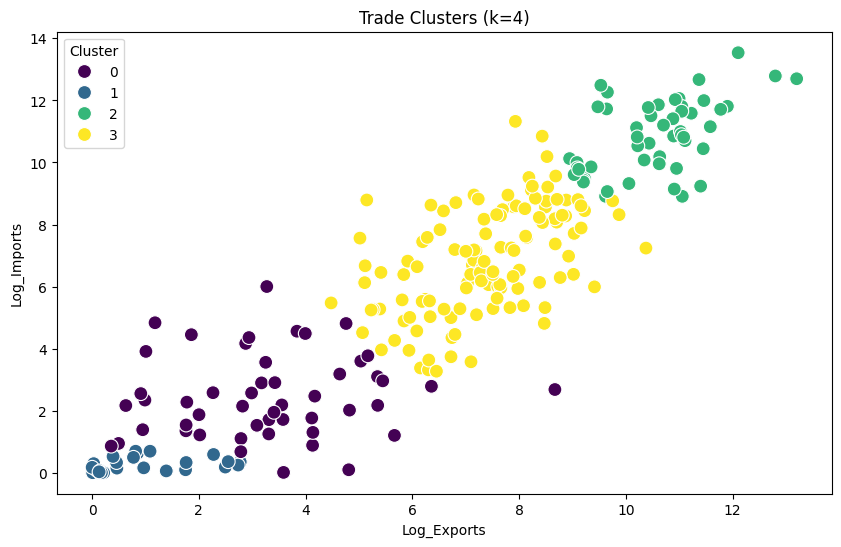

In [ ]:
# 5. Fit Final GMM
gmm = GaussianMixture(n_components=best_n_clusters, covariance_type='full', random_state=42)
country_summary_df['Cluster'] = gmm.fit_predict(X_scaled)

# Visualize
plt.figure(figsize=(10, 6))
sns.scatterplot(data=country_summary_df, x='Log_Exports', y='Log_Imports',
                hue='Cluster', palette='viridis', s=100)
plt.title(f'Trade Clusters (k={best_n_clusters})')
plt.show()

In [ ]:
# --- Cluster Profiling & Interpretation ---

# 1. Calculate aggregate stats for each cluster
cluster_profiles = country_summary_df.groupby('Cluster').agg({
    'Total_Exports_USD': 'mean',
    'Total_Imports_USD': 'mean',
    'Total_Trade_USD': 'mean'
}).reset_index()

# Count countries per cluster
cluster_profiles['Count'] = country_summary_df.groupby('Cluster').size().values

# 2. Sort by Total Trade Volume to rank them (Tier 1 = Highest Volume)
cluster_profiles = cluster_profiles.sort_values('Total_Trade_USD', ascending=False).reset_index(drop=True)

print("--- Cluster Interpretation & Labeling ---")
print(f"{'Cluster':<10} {'Label':<35} {'Countries':<10} {'Avg Trade Volume ($)':<20}")
print("-" * 80)

cluster_map = {} # To save for later use in regression

for index, row in cluster_profiles.iterrows():
    c_id = int(row['Cluster'])
    count = int(row['Count'])
    avg_vol = row['Total_Trade_USD']
    avg_exp = row['Total_Exports_USD']
    avg_imp = row['Total_Imports_USD']

    # A. Assign Tier Labels based on Rank
    if index == 0:
        tier_label = "Tier 1: Strategic Super-Partners"
    elif index == 1:
        tier_label = "Tier 2: Major Economies"
    elif index == len(cluster_profiles) - 1:
        tier_label = "Tier 4: Small/Low-Volume Economies"
    else:
        tier_label = "Tier 3: Developing Trade Partners"

    # B. Determine Trade Balance (Surplus vs Deficit)
    # If India exports > 1.2x Imports -> Surplus
    # If India imports > 1.2x Exports -> Deficit
    balance_label = "Balanced"
    if avg_exp > 1.2 * avg_imp:
        balance_label = "(Trade Surplus)"
    elif avg_imp > 1.2 * avg_exp:
        balance_label = "(Trade Deficit)"

    final_label = f"{tier_label} {balance_label}"
    cluster_map[c_id] = index # Map original ID to Rank (0=Highest)

    print(f"{c_id:<10} {final_label:<35} {count:<10} ${avg_vol:,.0f}")

print("-" * 80)

# 3. Show specific countries in the Top Cluster (Tier 1)
top_tier_id = cluster_profiles.iloc[0]['Cluster']
top_countries = country_summary_df[country_summary_df['Cluster'] == top_tier_id].index.tolist()
print(f"\n🌍 Countries in Tier 1 (Top Cluster {top_tier_id}):")
print(", ".join(top_countries))

--- Cluster Interpretation & Labeling ---
Cluster    Label                               Countries  Avg Trade Volume ($)
--------------------------------------------------------------------------------
2          Tier 1: Strategic Super-Partners (Trade Deficit) 52         $160,445
3          Tier 2: Major Economies Balanced    119        $6,732
0          Tier 3: Developing Trade Partners (Trade Surplus) 50         $209
1          Tier 4: Small/Low-Volume Economies (Trade Surplus) 27         $3
--------------------------------------------------------------------------------

🌍 Countries in Tier 1 (Top Cluster 2.0):
ALGERIA, ARGENTINA, AUSTRALIA, BANGLADESH PR, BELGIUM, BRAZIL, CANADA, CHILE, CHINA P RP, COLOMBIA, EGYPT A RP, FRANCE, GERMANY, GHANA, HONG KONG, INDONESIA, IRAN, IRAQ, ISRAEL, ITALY, JAPAN, JORDAN, KOREA RP, KUWAIT, MALAYSIA, MEXICO, MOZAMBIQUE, MYANMAR, NEPAL, NETHERLAND, NIGERIA, OMAN, PERU, POLAND, QATAR, RUSSIA, SAUDI ARAB, SINGAPORE, SOUTH AFRICA, SPAIN, SRI LANKA DSR

In [ ]:
# --- Generate Final Cluster Table ---

# 1. Create a list to store the table data
table_data = []

# Iterate through the sorted profiles (Rank 1 to Rank N)
for index, row in cluster_profiles.iterrows():
    c_id = int(row['Cluster'])

    # --- Re-apply the Labeling Logic ---
    # Determine Tier
    if index == 0:
        tier_label = "Tier 1: Strategic Super-Partners"
    elif index == 1:
        tier_label = "Tier 2: Major Economies"
    elif index == len(cluster_profiles) - 1:
        tier_label = "Tier 4: Small/Low-Volume Economies"
    else:
        tier_label = "Tier 3: Developing Trade Partners"

    # Determine Balance
    avg_exp = row['Total_Exports_USD']
    avg_imp = row['Total_Imports_USD']

    balance_label = "Balanced"
    if avg_exp > 1.2 * avg_imp:
        balance_label = "(Surplus)"
    elif avg_imp > 1.2 * avg_exp:
        balance_label = "(Deficit)"

    full_label = f"{tier_label} {balance_label}"

    # --- Retrieve Country Names ---
    # Filter the main dataframe for countries in this specific cluster
    countries_list = country_summary_df[country_summary_df['Cluster'] == c_id].index.tolist()
    countries_str = ", ".join(countries_list)

    # Append to data list
    table_data.append({
        "Rank": index + 1,
        "Cluster Label": full_label,
        "Count": len(countries_list),
        "Avg Volume ($)": f"${row['Total_Trade_USD']:,.0f}",
        "Countries": countries_str
    })

# 2. Convert to DataFrame
df_cluster_table = pd.DataFrame(table_data)

# 3. Display settings to ensure the list of countries isn't cut off (truncated)
pd.set_option('display.max_colwidth', None)

# Print the final table
print("\n=== FINAL CLUSTER CLASSIFICATION TABLE ===")
display(df_cluster_table) # Use display() if in Jupyter/Colab, otherwise use print(df_cluster_table)


=== FINAL CLUSTER CLASSIFICATION TABLE ===


,Rank,Cluster Label,Count,Avg Volume ($),Countries
0,1,Tier 1: Strategic Super-Partners (Deficit),52,"$160,445","ALGERIA, ARGENTINA, AUSTRALIA, BANGLADESH PR, BELGIUM, BRAZIL, CANADA, CHILE, CHINA P RP, COLOMBIA, EGYPT A RP, FRANCE, GERMANY, GHANA, HONG KONG, INDONESIA, IRAN, IRAQ, ISRAEL, ITALY, JAPAN, JORDAN, KOREA RP, KUWAIT, MALAYSIA, MEXICO, MOZAMBIQUE, MYANMAR, NEPAL, NETHERLAND, NIGERIA, OMAN, PERU, POLAND, QATAR, RUSSIA, SAUDI ARAB, SINGAPORE, SOUTH AFRICA, SPAIN, SRI LANKA DSR, SWEDEN, SWITZERLAND, TAIWAN, TANZANIA REP, THAILAND, TURKEY, U ARAB EMTS, U K, U S A, UNSPECIFIED, VIETNAM SOC REP"
1,2,Tier 2: Major Economies Balanced,119,"$6,732","AFGHANISTAN, ALBANIA, ANGOLA, ARMENIA, AUSTRIA, AZERBAIJAN, BAHAMAS, BAHARAIN IS, BELARUS, BENIN, BHUTAN, BOLIVIA, BOSNIA-HRZGOVIN, BOTSWANA, BRUNEI, BULGARIA, BURKINA FASO, BURUNDI, CAMBODIA, CAMEROON, CHAD, COMOROS, CONGO D. REP., CONGO P REP, COSTA RICA, COTE D' IVOIRE, CROATIA, CUBA, CYPRUS, CZECH REPUBLIC, DENMARK, DJIBOUTI, DOMINIC REP, ECUADOR, EL SALVADOR, EQUTL GUINEA, ERITREA, ESTONIA, ETHIOPIA, FINLAND, GABON, GAMBIA, GEORGIA, GREECE, GUATEMALA, GUINEA, GUINEA BISSAU, GUYANA, HAITI, HONDURAS, HUNGARY, ICELAND, IRELAND, JAMAICA, KAZAKHSTAN, KENYA, KOREA DP RP, KYRGHYZSTAN, LAO PD RP, LATVIA, LEBANON, LESOTHO, LIBERIA, LIBYA, LITHUANIA, LUXEMBOURG, MACEDONIA, MADAGASCAR, MALAWI, MALDIVES, MALI, MALTA, MAURITANIA, MAURITIUS, MONGOLIA, MOROCCO, NAMIBIA, NETHERLANDANTIL, NEW CALEDONIA, NEW ZEALAND, NICARAGUA, NIGER, NORWAY, PAKISTAN IR, PANAMA REPUBLIC, PAPUA N GNA, PARAGUAY, PHILIPPINES, PORTUGAL, PUERTO RICO, REUNION, ROMANIA, RWANDA, SENEGAL, SERBIA, SEYCHELLES, SIERRA LEONE, SLOVAK REP, SLOVENIA, SOMALIA, SOUTH SUDAN , SUDAN, SURINAME, SWAZILAND, SYRIA, TAJIKISTAN, TIMOR LESTE, TOGO, TRINIDAD, TUNISIA, TURKMENISTAN, UGANDA, UKRAINE, URUGUAY, UZBEKISTAN, VENEZUELA, YEMEN REPUBLC, ZAMBIA, ZIMBABWE"
2,3,Tier 3: Developing Trade Partners (Surplus),50,$209,"AMERI SAMOA, ANDORRA, ANTARTICA, ANTIGUA, ARUBA, BARBADOS, BELIZE, BERMUDA, BR VIRGN IS, C AFRI REP, CAPE VERDE IS, CAYMAN IS, COCOS IS, DOMINICA, FALKLAND IS, FAROE IS., FIJI IS, FR GUIANA, FR POLYNESIA, GIBRALTAR, GRENADA, GUADELOUPE, INSTALLATIONS IN INTERNATIONAL WATERS , LIECHTENSTEIN, MACAO, MARSHALL ISLAND, MARTINIQUE, MAYOTTE, MOLDOVA, MONACO, MONTENEGRO, NAURU RP, NORFOLK IS, PACIFIC IS, PALAU, PANAMA C Z, SAMOA, SAN MARINO, SOLOMON IS, ST KITT N A, ST LUCIA, ST VINCENT, STATE OF PALEST, TOKELAU IS, TUVALU, UNION OF SERBIA & MONTENEGRO, US MINOR OUTLYING ISLANDS , VANUATU REP, VIRGIN IS US, WALLIS F IS"
3,4,Tier 4: Small/Low-Volume Economies (Surplus),27,$3,"ANGUILLA, CANARY IS, CHANNEL IS, CHRISTMAS IS., COOK IS, CURACAO, FR S ANT TR, GREENLAND, GUAM, GUERNSEY, HEARD MACDONALD, JERSEY , KIRIBATI REP, MICRONESIA, MONTSERRAT, N. MARIANA IS., NEUTRAL ZONE, NIUE IS, PITCAIRN IS., SAHARWI A.DM RP, SAO TOME, SINT MAARTEN (DUTCH PART), ST HELENA, ST PIERRE, TONGA, TURKS C IS, VATICAN CITY"


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# --- Clustering Performance Matrix ---

# 1. Calculate Evaluation Metrics
sil_score = silhouette_score(X_scaled, country_summary_df['Cluster'])
db_score = davies_bouldin_score(X_scaled, country_summary_df['Cluster'])
ch_score = calinski_harabasz_score(X_scaled, country_summary_df['Cluster'])

# 2. Create a Summary DataFrame
scores_data = {
    'Metric': ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Score'],
    'Value': [sil_score, db_score, ch_score],
}

df_scores = pd.DataFrame(scores_data)

# 3. Print the Matrix
print("\n=== CLUSTERING PERFORMANCE MATRIX ===")
# Format the value column to show 4 decimal places
pd.options.display.float_format = '{:,.4f}'.format
display(df_scores)
print("-" * 60)


=== CLUSTERING PERFORMANCE MATRIX ===


,Metric,Value
0,Silhouette Score,0.3956
1,Davies-Bouldin Index,0.7430
2,Calinski-Harabasz Score,466.3497


------------------------------------------------------------


In [ ]:
SEED = 42
np.random.seed(SEED)

In [ ]:
# Ensure year exists
if 'year' not in df_export_data.columns:
    if 'date' in df_export_data.columns:
        df_export_data['year'] = pd.to_datetime(df_export_data['date']).dt.year
    else:
        raise ValueError("Export file missing 'year' or 'date' column")

if 'year' not in df_import_data.columns:
    if 'date' in df_import_data.columns:
        df_import_data['year'] = pd.to_datetime(df_import_data['date']).dt.year
    else:
        raise ValueError("Import file missing 'year' or 'date' column")

df_exp_yr = df_export_data.groupby(['country','year'])['value'].sum().reset_index(name='Exports_USD')
df_imp_yr = df_import_data.groupby(['country','year'])['value'].sum().reset_index(name='Imports_USD')

In [ ]:
# Inner merge
df_trade_yr = pd.merge(df_exp_yr, df_imp_yr, on=['country','year'], how='inner')
df_trade_yr['Total_USD'] = df_trade_yr['Exports_USD'] + df_trade_yr['Imports_USD']
df_trade_yr = df_trade_yr[df_trade_yr['Total_USD'] > 1000]   # remove tiny noise USD rows

In [ ]:
df_exchange = pd.read_csv('USD_INR_Exchange.csv')
df_exchange['Date'] = pd.to_datetime(df_exchange['Date'])
df_exchange['year'] = df_exchange['Date'].dt.year

df_yearly_rate = df_exchange.groupby('year')['Close'].mean().reset_index(name='Exchange_Rate')

master_df = pd.merge(df_trade_yr, df_yearly_rate, on='year', how='left')
master_df = master_df.sort_values('year').reset_index(drop=True)

In [ ]:
# Global forward/backfill for exchange rate
master_df['Exchange_Rate'] = master_df['Exchange_Rate'].ffill().bfill()
master_df = master_df.dropna(subset=['Exchange_Rate'])

# Target variable
master_df['Total_Trade_INR'] = (master_df['Exports_USD'] + master_df['Imports_USD']) * master_df['Exchange_Rate']

# Remove tiny INR rows that blow up percentage metrics
master_df = master_df[master_df['Total_Trade_INR'] > 100_000]

In [ ]:
# 3. Add Cluster as Feature
if 'cluster_map' in globals():
    master_df['Cluster'] = master_df['country'].map(cluster_map).fillna(-1).astype(int)
else:
    master_df['Cluster'] = -1

In [ ]:
# 4. Lag Features

master_df = master_df.sort_values(['country','year']).reset_index(drop=True)
master_df['Prev_Exports'] = master_df.groupby('country')['Exports_USD'].shift(1)
master_df['Prev_Imports'] = master_df.groupby('country')['Imports_USD'].shift(1)
master_df['Prev_Rate'] = master_df.groupby('country')['Exchange_Rate'].shift(1)

model_data = master_df.dropna(subset=['Prev_Exports','Prev_Imports','Prev_Rate','Total_Trade_INR'])

In [ ]:
# 5. Train/Test Split

X = model_data[['Prev_Exports','Prev_Imports','Prev_Rate','Cluster']]
y = model_data['Total_Trade_INR']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)


=== REGRESSION PERFORMANCE MATRIX ===


,R2 Score,MAE (INR),RMSE (INR),MAPE (%)
Model,,,,
Random Forest,0.9428,"122,044.8817","274,763.4901",0.2109
XGBoost,0.9309,"135,215.9952","301,924.4295",0.2112
Ensemble (RF + XGB),0.9387,"126,951.5999","284,411.3376",0.2065


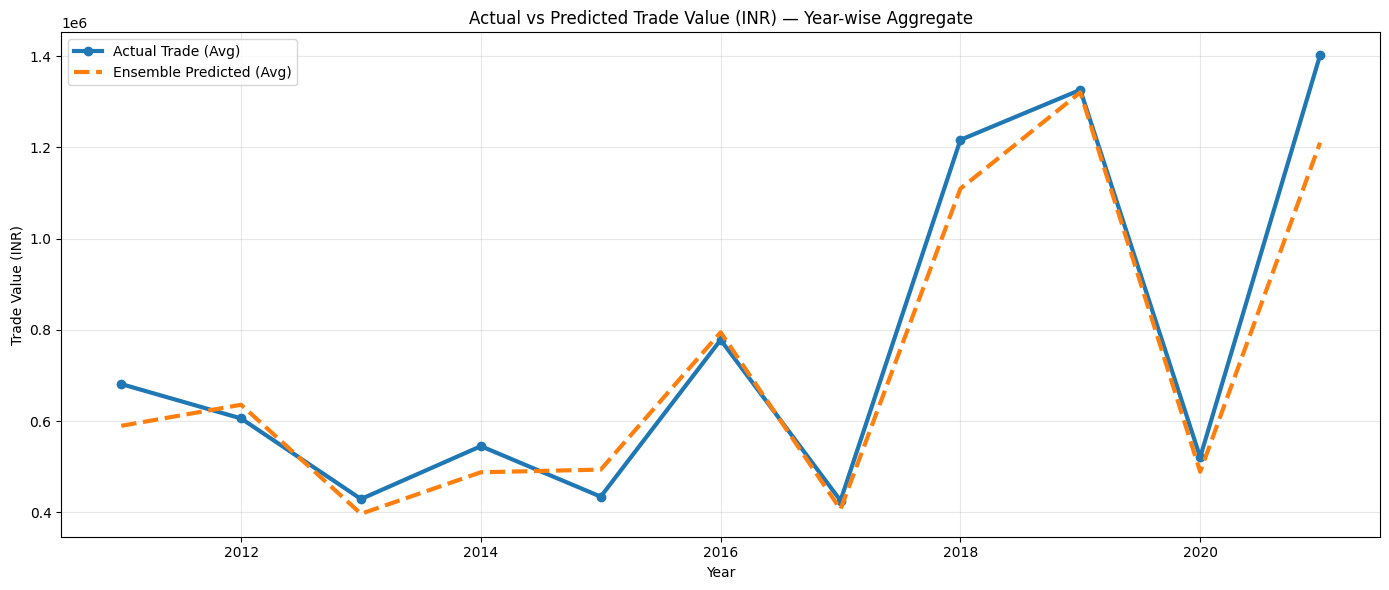

In [ ]:
# Log-Transform the Target
# We use log1p to handle the scale difference (compresses billions vs millions)
y_log = np.log1p(model_data['Total_Trade_INR'])

# Split Data (Using same random_state=42 ensures a fair comparison to your previous run)
X = model_data[['Prev_Exports', 'Prev_Imports', 'Prev_Rate', 'Cluster']]
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- 1. Initialize & Train Models Separately ---

# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train_log)

# XGBoost
xgb = XGBRegressor(
    n_estimators=300, learning_rate=0.07, max_depth=5,
    subsample=0.9, colsample_bytree=0.9, random_state=42, n_jobs=-1, verbosity=0
)
xgb.fit(X_train, y_train_log)

# Ensemble (Voting)
ensemble_log = VotingRegressor([('rf', rf), ('xgb', xgb)])
ensemble_log.fit(X_train, y_train_log)

# --- 2. Predict & Inverse Transform (Back to INR) ---

# Actual Values
y_test_actual = np.expm1(y_test_log)

# Random Forest Predictions
y_pred_rf = np.expm1(rf.predict(X_test))

# XGBoost Predictions
y_pred_xgb = np.expm1(xgb.predict(X_test))

# Ensemble Predictions
y_pred_ens = np.expm1(ensemble_log.predict(X_test))

# --- 3. Generate Performance Matrix ---

def calculate_metrics(model_name, y_true, y_pred):
    return {
        'Model': model_name,
        'R2 Score': r2_score(y_true, y_pred),
        'MAE (INR)': mean_absolute_error(y_true, y_pred),
        'RMSE (INR)': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE (%)': mean_absolute_percentage_error(y_true, y_pred)
    }

# Compile metrics into a list
metrics_data = [
    calculate_metrics('Random Forest', y_test_actual, y_pred_rf),
    calculate_metrics('XGBoost', y_test_actual, y_pred_xgb),
    calculate_metrics('Ensemble (RF + XGB)', y_test_actual, y_pred_ens)
]

# Create DataFrame
df_perf_matrix = pd.DataFrame(metrics_data).set_index('Model')

# Formatting for clean output
pd.options.display.float_format = '{:,.4f}'.format

print("\n=== REGRESSION PERFORMANCE MATRIX ===")
display(df_perf_matrix) # Use print(df_perf_matrix) if not in Notebook

# --- 4. Visualization (Using the Best Model - Ensemble) ---

# Build a dataframe with actual + predicted + year + country
viz_df = model_data.loc[y_test.index, ['country','year','Total_Trade_INR']].copy()
viz_df['Predicted_INR'] = y_pred_ens  # We use the Ensemble for the final plot

# Sort for proper plotting
viz_df = viz_df.sort_values(['country','year'])

# Aggregate by Year for the Plot
avg_df = viz_df.groupby('year')[['Total_Trade_INR','Predicted_INR']].mean().reset_index()

plt.figure(figsize=(14,6))
plt.plot(avg_df['year'], avg_df['Total_Trade_INR'], label='Actual Trade (Avg)', linewidth=3, marker='o')
plt.plot(avg_df['year'], avg_df['Predicted_INR'], label='Ensemble Predicted (Avg)', linewidth=3, linestyle='--')

plt.title("Actual vs Predicted Trade Value (INR) — Year-wise Aggregate")
plt.xlabel("Year")
plt.ylabel("Trade Value (INR)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


   DETAILED NUMERICAL PREDICTIONS (TOP 5 FITS)

🔹 Country: ALGERIA
   Model Accuracy: 99.98% (Error: 0.02%)


,Year,Actual Trade (INR),Predicted Trade (INR),Difference
4,2017,"135,698","135,722",-25


------------------------------------------------------------

🔹 Country: UKRAINE
   Model Accuracy: 96.61% (Error: 3.39%)


,Year,Actual Trade (INR),Predicted Trade (INR),Difference
635,2014,"157,784","163,131","-5,347"


------------------------------------------------------------

🔹 Country: GERMANY
   Model Accuracy: 96.20% (Error: 3.80%)


...

------------------------------------------------------------

🔹 Country: FRANCE
   Model Accuracy: 96.10% (Error: 3.90%)


,Year,Actual Trade (INR),Predicted Trade (INR),Difference
154,2021,"918,477","954,290","-35,812"


------------------------------------------------------------

🔹 Country: JAPAN
   Model Accuracy: 96.03% (Error: 3.97%)


,Year,Actual Trade (INR),Predicted Trade (INR),Difference
253,2012,"988,615","1,010,142","-21,528"
262,2021,"1,521,310","1,608,889","-87,579"


------------------------------------------------------------

Generating Validation Plots...


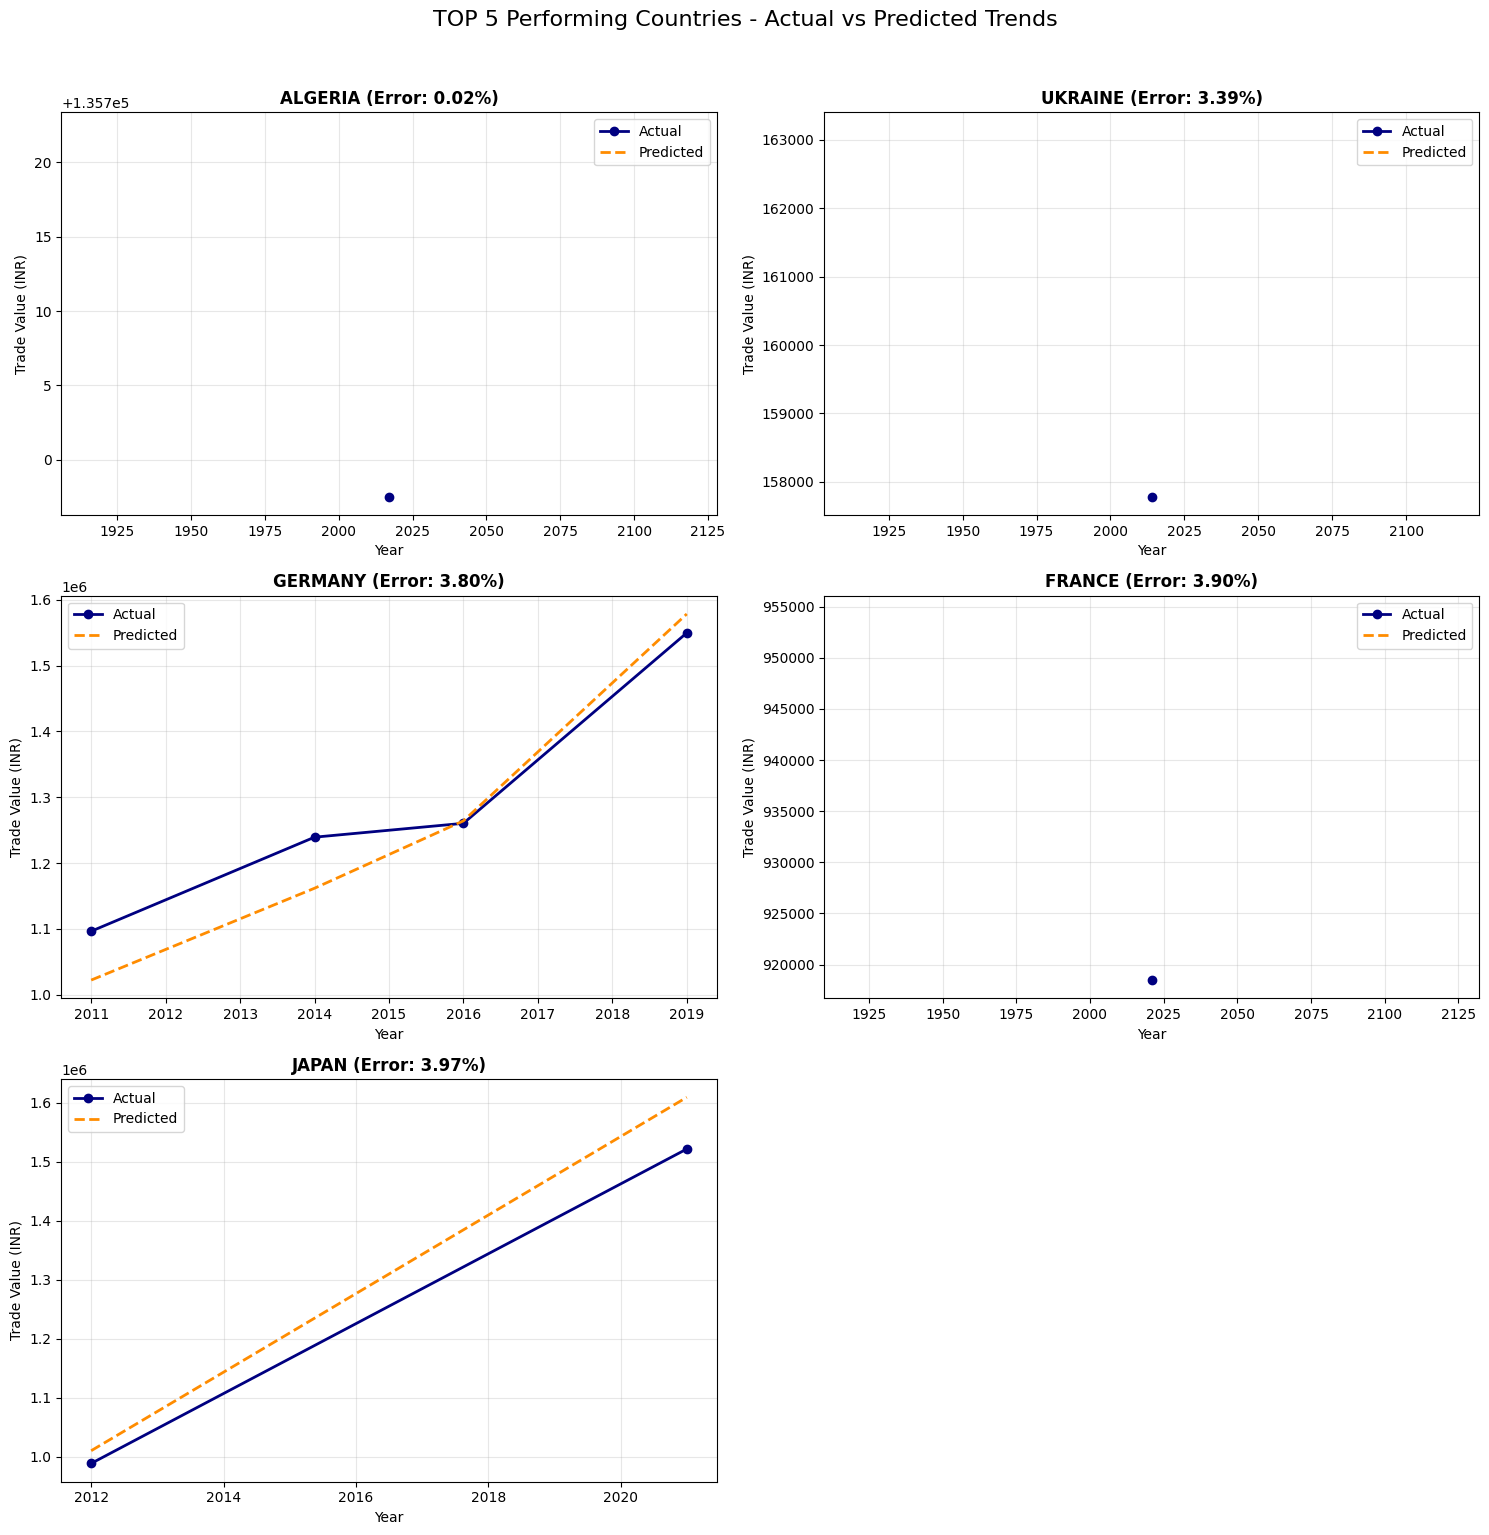

In [ ]:
# --- Advanced Visualization & Numerical Validation ---

# 1. Calculate MAPE per Country to find the best fits
country_metrics = viz_df.groupby('country').apply(
    lambda x: mean_absolute_percentage_error(x['Total_Trade_INR'], x['Predicted_INR'])
).reset_index(name='Country_MAPE').sort_values('Country_MAPE')

# Select only the Top 5 (Lowest Error)
best_countries = country_metrics.head(5)

# --- PART 1: PRINT THE NUMBERS (Proof of Accuracy) ---
print("\n" + "="*50)
print("   DETAILED NUMERICAL PREDICTIONS (TOP 5 FITS)")
print("="*50)

# Set pandas to format numbers with commas for readability (e.g. 1,000,000)
pd.options.display.float_format = '{:,.0f}'.format

for index, row in best_countries.iterrows():
    c_name = row['country']
    c_mape = row['Country_MAPE']

    print(f"\n🔹 Country: {c_name.upper()}")
    print(f"   Model Accuracy: {100 - (c_mape*100):.2f}% (Error: {c_mape:.2%})")

    # Get the data for this country
    country_data = viz_df[viz_df['country'] == c_name].copy()

    # Calculate Difference
    country_data['Diff_INR'] = country_data['Total_Trade_INR'] - country_data['Predicted_INR']

    # Select and Rename Columns for the Report
    table_view = country_data[['year', 'Total_Trade_INR', 'Predicted_INR', 'Diff_INR']].sort_values('year')
    table_view.columns = ['Year', 'Actual Trade (INR)', 'Predicted Trade (INR)', 'Difference']

    # Display the table
    display(table_view)
    print("-" * 60)

# --- PART 2: VISUALIZATION (Visual Proof) ---

def plot_country_results(country_list, title_prefix):
    n = len(country_list)
    rows = (n // 2) + (n % 2)

    fig, axes = plt.subplots(rows, 2, figsize=(15, 5 * rows))
    axes = axes.flatten()

    for i, row in enumerate(country_list.itertuples()):
        country_name = row.country
        mape_val = row.Country_MAPE

        subset = viz_df[viz_df['country'] == country_name]

        ax = axes[i]
        ax.plot(subset['year'], subset['Total_Trade_INR'], label='Actual', marker='o', linewidth=2, color='navy')
        ax.plot(subset['year'], subset['Predicted_INR'], label='Predicted', linestyle='--', linewidth=2, color='darkorange')

        ax.set_title(f"{country_name} (Error: {mape_val:.2%})", fontweight='bold')
        ax.set_xlabel("Year")
        ax.set_ylabel("Trade Value (INR)")
        ax.legend()
        ax.grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f"{title_prefix} - Actual vs Predicted Trends", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

print("\nGenerating Validation Plots...")
plot_country_results(best_countries, "TOP 5 Performing Countries")

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
# We fetch 5 years of data to ensure the LSTM has enough history to learn patterns
print("Downloading data...")
df = yf.download('INR=X', period='5y', interval='1d')

# Use only the 'Close' price for prediction
data = df[['Close']].values

[*********************100%***********************]  1 of 1 completed


In [ ]:
# LSTM models are sensitive to scale. We normalize data between 0 and 1.
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [ ]:
# The model will look at the past 60 days to predict the next day.
prediction_days = 60
x_train = []
y_train = []
training_data_len = int(len(scaled_data) * 0.8)

for x in range(prediction_days, training_data_len):
    x_train.append(scaled_data[x-prediction_days:x, 0])
    y_train.append(scaled_data[x, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [ ]:
model = Sequential()

# Layer 1: LSTM with 50 units, return_sequences=True because we have another LSTM layer next
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2)) # Dropout prevents overfitting

# Layer 2: LSTM with 50 units
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Layer 3: Dense layer (Output)
model.add(Dense(units=1)) # Prediction of the next closing price

model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
print("Training model... (This may take a few minutes)")
model.fit(x_train, y_train, epochs=25, batch_size=32)

Training model... (This may take a few minutes)
Epoch 1/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0636
Epoch 2/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0045
Epoch 3/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0034
Epoch 4/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0027
Epoch 5/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0026
Epoch 6/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0025
Epoch 7/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0026
Epoch 8/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0024
Epoch 9/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0021
Epoch 10/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0021
Epoch 11/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0023
Epoch 12/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0020
Epoch 13/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0019
Epoch 14/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0021
Epoch 15/25
31/31 ━━━━━━━━━━━━━━━━━━

In [ ]:
test_data = scaled_data[training_data_len - prediction_days: , :]
x_test = []
y_test = data[training_data_len:, :] # Actual values for comparison

for x in range(prediction_days, len(test_data)):
    x_test.append(test_data[x-prediction_days:x, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [ ]:
# Get predicted prices
predictions = model.predict(x_test)
# Inverse transform to get back the actual INR values (not 0-1 scale)
predictions = scaler.inverse_transform(predictions)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step


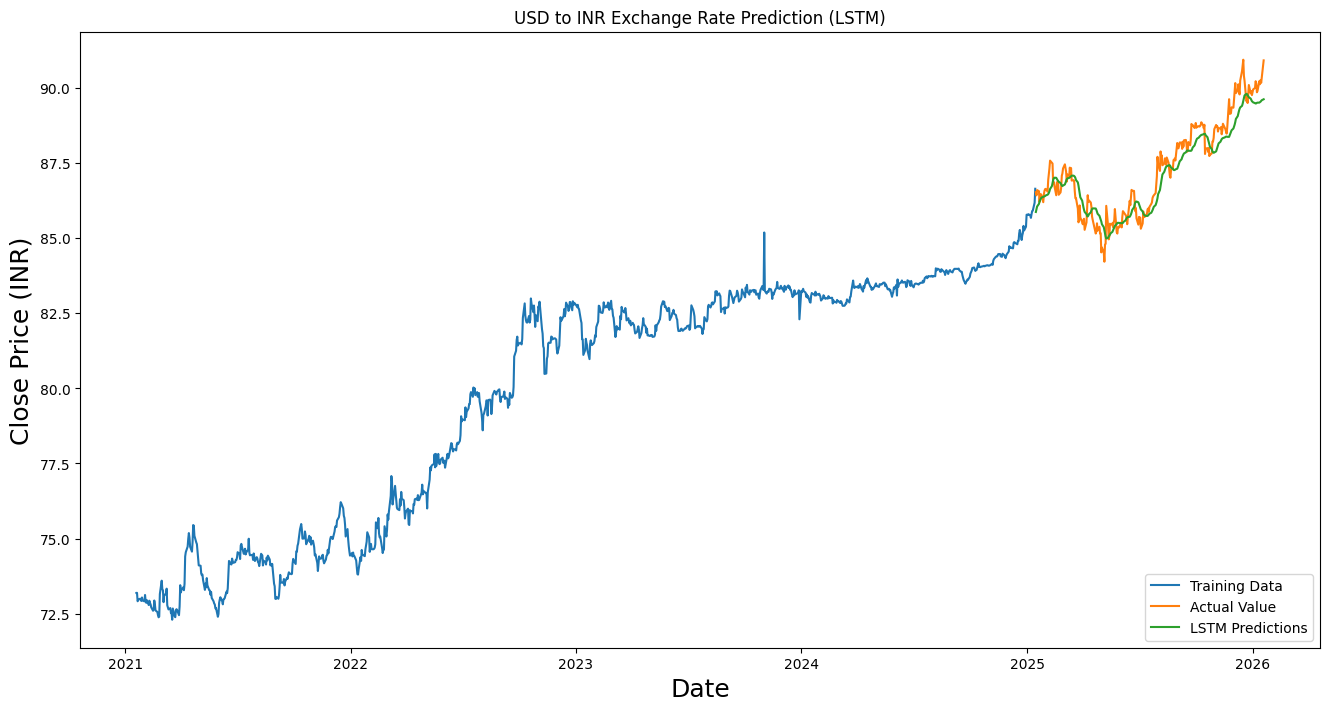

In [ ]:
train = df[:training_data_len]
valid = df[training_data_len:].copy()
valid['Predictions'] = predictions

plt.figure(figsize=(16,8))
plt.title('USD to INR Exchange Rate Prediction (LSTM)')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price (INR)', fontsize=18)
plt.plot(train['Close'], label='Training Data')
plt.plot(valid['Close'], label='Actual Value')
plt.plot(valid['Predictions'], label='LSTM Predictions')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# ==========================================
#      PERFORMANCE MATRIX & SAMPLE OUTPUTS
# ==========================================

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# --- 1. Calculate Error Metrics ---
rmse = np.sqrt(mean_squared_error(valid['Close'], valid['Predictions']))
mae = mean_absolute_error(valid['Close'], valid['Predictions'])
mape = mean_absolute_percentage_error(valid['Close'], valid['Predictions'])

# Create a clean dataframe for the matrix
metrics_data = {
    'Metric': ['Root Mean Squared Error (RMSE)', 'Mean Absolute Error (MAE)', 'Mean Absolute Percentage Error (MAPE)'],
    'Value': [rmse, mae, mape],
    'Interpretation': [
        'Lower is better (Standard Deviation of errors)',
        f'On average, the prediction is off by ₹{mae:.2f}',
        f'The model is {100-(mape*100):.2f}% accurate'
    ]
}

df_metrics = pd.DataFrame(metrics_data)

print("\n" + "="*50)
print("   LSTM MODEL PERFORMANCE MATRIX")
print("="*50)
# Format for cleaner output
pd.options.display.float_format = '{:,.4f}'.format
display(df_metrics) # Use print(df_metrics) if not in Jupyter/Colab

# --- 2. Sample Outputs (Reality Check) ---
# We show the last 10 days of trading to see how the model tracks current prices
print("\n" + "="*50)
print("   SAMPLE OUTPUTS (LAST 10 TRADING DAYS)")
print("="*50)

# Create a comparison table
comparison_df = valid[['Close', 'Predictions']].tail(10).copy()
comparison_df.columns = ['Actual Price (INR)', 'Predicted Price (INR)']
comparison_df['Difference (INR)'] = comparison_df['Actual Price (INR)'] - comparison_df['Predicted Price (INR)']
comparison_df['Accuracy (%)'] = 100 - (abs(comparison_df['Difference (INR)']) / comparison_df['Actual Price (INR)'] * 100)

pd.options.display.float_format = '{:,.2f}'.format
display(comparison_df) # Use print(comparison_df) if not in Jupyter/Colab
print("-" * 50)


   LSTM MODEL PERFORMANCE MATRIX


,Metric,Value,Interpretation
0,Root Mean Squared Error (RMSE),0.5334,Lower is better (Standard Deviation of errors)
1,Mean Absolute Error (MAE),0.4446,"On average, the prediction is off by ₹0.44"
2,Mean Absolute Percentage Error (MAPE),0.0051,The model is 99.49% accurate



   SAMPLE OUTPUTS (LAST 10 TRADING DAYS)


,Actual Price (INR),Predicted Price (INR),Difference (INR),Accuracy (%)
Date,,,,
2026-01-06,90.23,89.49,0.74,99.18
2026-01-07,90.17,89.50,0.67,99.26
2026-01-08,89.86,89.51,0.35,99.61
2026-01-09,89.91,89.52,0.39,99.57
2026-01-12,90.24,89.52,0.72,99.21
2026-01-13,90.13,89.54,0.60,99.34
2026-01-14,90.27,89.55,0.72,99.20
2026-01-15,90.18,89.58,0.61,99.33
2026-01-16,90.36,89.60,0.76,99.16


--------------------------------------------------


In [ ]:
!pip install prophet yfinance

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet


In [ ]:
df = yf.download('INR=X', period='max', interval='1d')

[*********************100%***********************]  1 of 1 completed


In [ ]:
# Flatten multi-level columns by dropping the second level (ticker symbol)
df.columns = df.columns.droplevel(1)

In [ ]:
# This removes daily noise and gives a clearer long-term trend for 2030.
df_month = df['Close'].resample('ME').last().reset_index()

In [ ]:
# Prophet REQUIRES specific column names: 'ds' (Date) and 'y' (Value)
df_prophet = pd.DataFrame()
df_prophet['ds'] = df_month['Date']
df_prophet['y'] = df_month['Close'].values

In [ ]:
# Remove any timezone information to prevent errors
df_prophet['ds'] = df_prophet['ds'].dt.tz_localize(None)

In [ ]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

model.fit(df_prophet)

In [ ]:
# 60 months = 5 years (2025 -> 2030)
future = model.make_future_dataframe(periods=65, freq='M')

# Generate the forecast
forecast = model.predict(future)

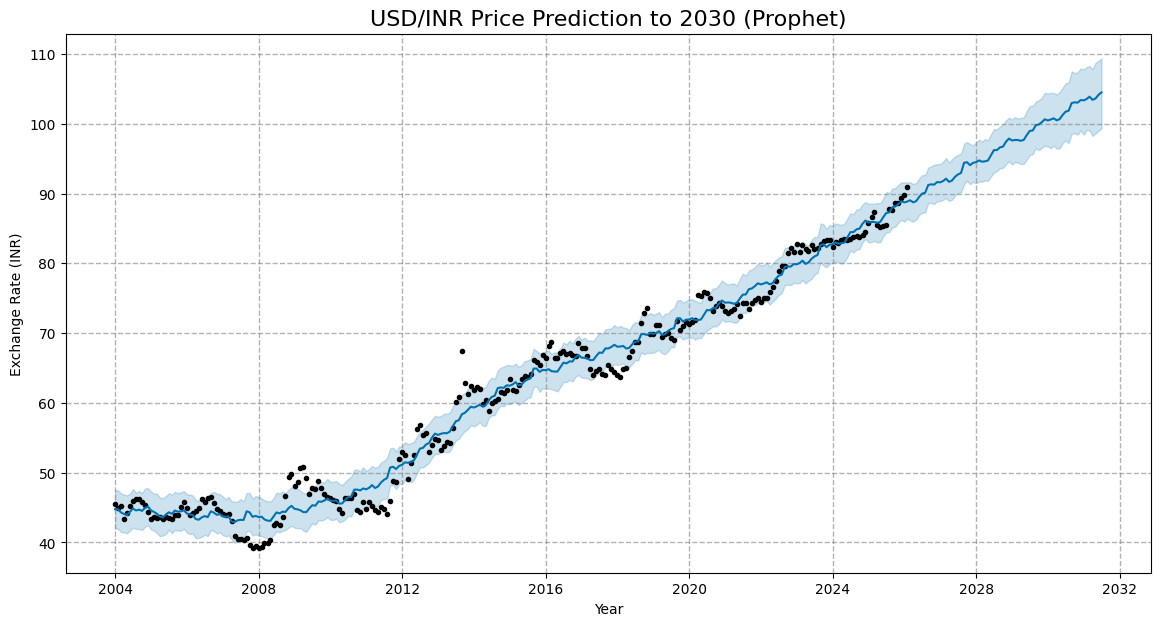

In [ ]:
# Plot 1: The Main Forecast
plt.figure(figsize=(14, 7))
model.plot(forecast, ax=plt.gca())
plt.title('USD/INR Price Prediction to 2030 (Prophet)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Exchange Rate (INR)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# ==========================================
# EXTRACT CLEAR PREDICTIONS (The Data Table)
# ==========================================

# 1. Select only the columns you care about
# ds = Date, yhat = Prediction, yhat_lower/upper = The Risk Range
clean_forecast = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()

# 2. Rename them to plain English
clean_forecast.columns = ['Date', 'Predicted_Rate', 'Minimum_Risk', 'Maximum_Risk']

# 3. Filter for FUTURE dates only (e.g., after Jan 1, 2025)
future_only = clean_forecast[clean_forecast['Date'] > '2025-01-01']

# 4. Create a "Yearly Snapshot" (Filter for January of each year)
# This prevents you from staring at 2,000 rows of daily data
yearly_snapshot = future_only[future_only['Date'].dt.month == 1]

# 5. Format the numbers for readability (2 decimal places)
pd.options.display.float_format = '{:,.2f}'.format

print("\n" + "="*50)
print("USD/INR YEARLY PRICE TARGETS (2025-2030)")
print("="*50)
print(yearly_snapshot.to_string(index=False))
print("-" * 50)

# Optional: Save to CSV so you can put it in your report
yearly_snapshot.to_csv('Final_Forecast_Targets_2030.csv', index=False)
print("Saved clear data to 'Final_Forecast_Targets_2030.csv'")


USD/INR YEARLY PRICE TARGETS (2025-2030)
      Date  Predicted_Rate  Minimum_Risk  Maximum_Risk
2025-01-31           85.93         83.04         88.54
2026-01-31           88.86         86.43         91.59
2027-01-31           91.80         89.09         94.60
2028-01-31           94.74         91.69         97.74
2029-01-31           97.68         94.50        100.96
2030-01-31          100.61         96.48        104.45
2031-01-31          103.55         99.12        108.13
--------------------------------------------------
Saved clear data to 'Final_Forecast_Targets_2030.csv'


In [ ]:
future_forecast = forecast[forecast['ds'] > '2025-12-01'][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
# Optional: Save to CSV
future_forecast.to_csv('USD_INR_Prophet_Forecast_2030.csv', index=False)
print("\nSaved predictions to 'USD_INR_Prophet_Forecast_2030.csv'")


--- Long-Term Prediction Snapshot ---
Dec 2026 Forecast: 91.65 INR
Dec 2028 Forecast: 97.88 INR
Dec 2030 Forecast: 104.49 INR

Saved predictions to 'USD_INR_Prophet_Forecast_2030.csv'


In [ ]:
# ==========================================
#      1. PROPHET PERFORMANCE MATRIX
# ==========================================

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

# Merge actuals with forecast to evaluate accuracy
performance_df = pd.merge(df_prophet, forecast[['ds', 'yhat']], on='ds', how='inner')

y_true = performance_df['y']
y_pred = performance_df['yhat']

# Calculate Metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = mean_absolute_percentage_error(y_true, y_pred)

prophet_scores = {
    'Metric': ['MAE (Mean Absolute Error)', 'RMSE (Root Mean Squared Error)', 'MAPE (Accuracy Score)'],
    'Value': [mae, rmse, mape],
    'Interpretation': [
        f'On average, the trend line is off by ₹{mae:.2f}',
        'Standard Deviation of the error',
        f'The model is {100 - (mape*100):.2f}% accurate'
    ]
}

df_prophet_scores = pd.DataFrame(prophet_scores)

print("\n" + "="*60)
print("   [1] MODEL DIAGNOSTICS (HISTORICAL FIT)")
print("="*60)
pd.options.display.float_format = '{:,.4f}'.format
display(df_prophet_scores)

# ==========================================
#      2. SAMPLE OUTPUTS (REALITY CHECK)
# ==========================================

print("\n" + "="*60)
print("   [2] REALITY CHECK: LAST 6 MONTHS")
print("="*60)

# Check the last 6 months of KNOWN data
sample_check = performance_df.tail(6).copy()
sample_check = sample_check[['ds', 'y', 'yhat']]
sample_check.columns = ['Date', 'Actual Price', 'Model Trend']

# Calculate deviation
sample_check['Diff'] = sample_check['Actual Price'] - sample_check['Model Trend']
sample_check['Accuracy %'] = 100 - (abs(sample_check['Diff']) / sample_check['Actual Price'] * 100)

pd.options.display.float_format = '{:,.2f}'.format
display(sample_check)

# ==========================================
#      3. LONG-TERM FORECAST VALUES
# ==========================================

print("\n" + "="*60)
print("   [3] LONG-TERM FORECAST (END-OF-YEAR TARGETS)")
print("="*60)

# Filter for future dates only
future_vals = forecast[forecast['ds'] > pd.Timestamp.now()]

# Select December of each year to get the "End of Year" target
eoy_forecast = future_vals[future_vals['ds'].dt.month == 12].copy()

# Clean up the table
eoy_report = eoy_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
eoy_report.columns = ['Date', 'Predicted Rate', 'Min Risk (Lower)', 'Max Risk (Upper)']
eoy_report['Year'] = eoy_report['Date'].dt.year

# Reorder columns
eoy_report = eoy_report[['Year', 'Predicted Rate', 'Min Risk (Lower)', 'Max Risk (Upper)']]

pd.options.display.float_format = '{:,.2f}'.format
display(eoy_report.set_index('Year'))
print("-" * 60)


   [1] MODEL DIAGNOSTICS (HISTORICAL FIT)


,Metric,Value,Interpretation
0,MAE (Mean Absolute Error),1.6427,"On average, the trend line is off by ₹1.64"
1,RMSE (Root Mean Squared Error),2.1316,Standard Deviation of the error
2,MAPE (Accuracy Score),0.0295,The model is 97.05% accurate



   [2] REALITY CHECK: LAST 6 MONTHS


,Date,Actual Price,Model Trend,Diff,Accuracy %
260,2025-08-31,87.59,88.04,-0.45,99.49
261,2025-09-30,88.70,88.15,0.56,99.37
262,2025-10-31,88.63,88.47,0.16,99.82
263,2025-11-30,89.36,88.89,0.48,99.46
264,2025-12-31,89.77,88.72,1.04,98.84
265,2026-01-31,90.93,88.86,2.07,97.73



   [3] LONG-TERM FORECAST (END-OF-YEAR TARGETS)


,Predicted Rate,Min Risk (Lower),Max Risk (Upper)
Year,,,
2026,91.60,88.91,94.22
2027,94.49,91.48,97.33
2028,97.60,94.17,100.61
2029,100.48,96.73,104.34
2030,103.35,98.45,107.80


------------------------------------------------------------
